**TP  pour compression d'image**


https://lindevs.com/color-quantization-using-k-means-clustering-and-scikit-learn/

Lisez le tutorial

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

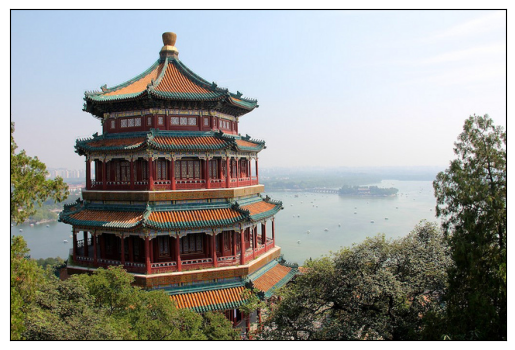

In [3]:
# On importe l'image
from sklearn.datasets import load_sample_image
image = load_sample_image("china.jpg")

plt.axes(xticks=[], yticks=[])
plt.imshow(image)

In [4]:
# Dimension de l'image originale
print("Shape de l'image :", image.shape)
# (427, 640, 3) => 427 lignes, 640 colonnes, 3 canaux RGB
print("Nombre de pixels :", image.shape[0] * image.shape[1])
print("Nombre de couleurs par pixel : 3 (R, G, B)")

Shape de l'image : (427, 640, 3)
Nombre de pixels : 273280
Nombre de couleurs par pixel : 3 (R, G, B)


**Réponse :** Il y a 427 × 640 = 273 280 pixels, et 3 couleurs (canaux RGB) par pixel.

In [5]:
rows = image.shape[0]
cols = image.shape[1]

# On aplatit l'image : chaque pixel devient une ligne avec 3 valeurs RGB
image_p = image.reshape(rows * cols, 3)
print("Shape après reshape :", image_p.shape)

Shape après reshape : (273280, 3)


In [6]:
print(image_p[0, :])
# Affiche les valeurs RGB (entre 0 et 255) du premier pixel de l'image

[174 201 231]


**Comparaison :**
- `image.shape` = (427, 640, 3) : image 2D avec 3 canaux
- `image_p.shape` = (273280, 3) : tableau 2D où chaque ligne est un pixel (vecteur RGB)

`image_p` représente l'image aplatie : chaque pixel est une ligne avec ses 3 composantes RGB.

In [7]:
# Normalisation : on ramène les valeurs de [0, 255] vers [0.0, 1.0]
image_p = image_p / 255.0

print(image_p[0, :])
# Affiche les valeurs RGB normalisées du premier pixel

[0.68235294 0.78823529 0.90588235]


In [8]:
# Affichage des 50 premiers éléments
print(image_p[:50, :])
# On constate que les valeurs sont toutes entre 0 et 1.
# Les pixels du ciel (haut de l'image) ont une forte composante bleue (3e colonne).

[[0.68235294 0.78823529 0.90588235]
 [0.68235294 0.78823529 0.90588235]
 [0.68235294 0.78823529 0.90588235]
 [0.68235294 0.78823529 0.90588235]
 [0.68235294 0.78823529 0.90588235]
 [0.68235294 0.78823529 0.90588235]
 [0.68235294 0.78823529 0.90588235]
 [0.68235294 0.78823529 0.90588235]
 [0.67843137 0.79215686 0.90980392]
 [0.6745098  0.78823529 0.90588235]
 [0.6745098  0.78823529 0.90588235]
 [0.67843137 0.79215686 0.90980392]
 [0.6745098  0.78823529 0.90588235]
 [0.6745098  0.78823529 0.90588235]
 [0.6745098  0.78823529 0.90588235]
 [0.68235294 0.79607843 0.91372549]
 [0.68627451 0.8        0.91764706]
 [0.68235294 0.79607843 0.91372549]
 [0.67843137 0.79215686 0.90980392]
 [0.68235294 0.79607843 0.91372549]
 [0.69019608 0.79607843 0.91372549]
 [0.69019608 0.79607843 0.91372549]
 [0.68627451 0.79215686 0.90980392]
 [0.69019608 0.79607843 0.91372549]
 [0.69411765 0.8        0.91764706]
 [0.69411765 0.8        0.91764706]
 [0.69019608 0.79607843 0.91372549]
 [0.69019608 0.79607843 0.91

Les trois dimensions sont les intensités des couleurs RGB (Red, Green, Blue).

L'intensité de chaque couleur est codée sur 8 bits (0–255), soit 2^8 = 256 niveaux par canal.
Par pixel, il y a donc (2^8)^3 = 2^24 = 16 777 216 couleurs différentes possibles.

Nous allons faire du clustering KMeans pour regrouper les couleurs similaires (compression d'image).

In [9]:
from sklearn.cluster import KMeans

model2 = KMeans(n_clusters=2, random_state=42, n_init=10)
model2.fit(image_p)

centers = model2.cluster_centers_  # Les 2 couleurs représentatives (centroides)
labels = model2.labels_             # Le cluster (0 ou 1) assigné à chaque pixel

print("Centers (couleurs représentatives normalisées) :")
print(centers)
print("\n1000 premières valeurs de labels :")
print(labels[:1000])
print("\n1000 dernières valeurs de labels :")
print(labels[-1000:])
print("\nCouleurs utilisées (en RGB 0-255) :")
print((centers * 255).astype(int))

Centers (couleurs représentatives normalisées) :
[[0.82404759 0.85468641 0.88413119]
 [0.28302308 0.25523655 0.18494591]]

1000 premières valeurs de labels :
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 

**Réponses :**
- `centers` : les coordonnées RGB (normalisées) des 2 centroides = les 2 couleurs représentatives
- `labels` : pour chaque pixel, l'indice (0 ou 1) du cluster auquel il appartient

In [10]:
# Reconstruction de l'image avec 2 couleurs seulement
new_colors = centers[labels]  # équivalent à [centers[l] for l in labels]
img = np.reshape(new_colors, image.shape)

**Explications :**
- `centers[labels]` : pour chaque pixel, on prend la couleur du centroïde de son cluster
- `new_colors` : tableau de 273 280 vecteurs RGB (un par pixel), chacun remplacé par la couleur de son centre
- `np.reshape(new_colors, image.shape)` : on remet en forme (427, 640, 3) pour afficher l'image

(427, 640, 3)


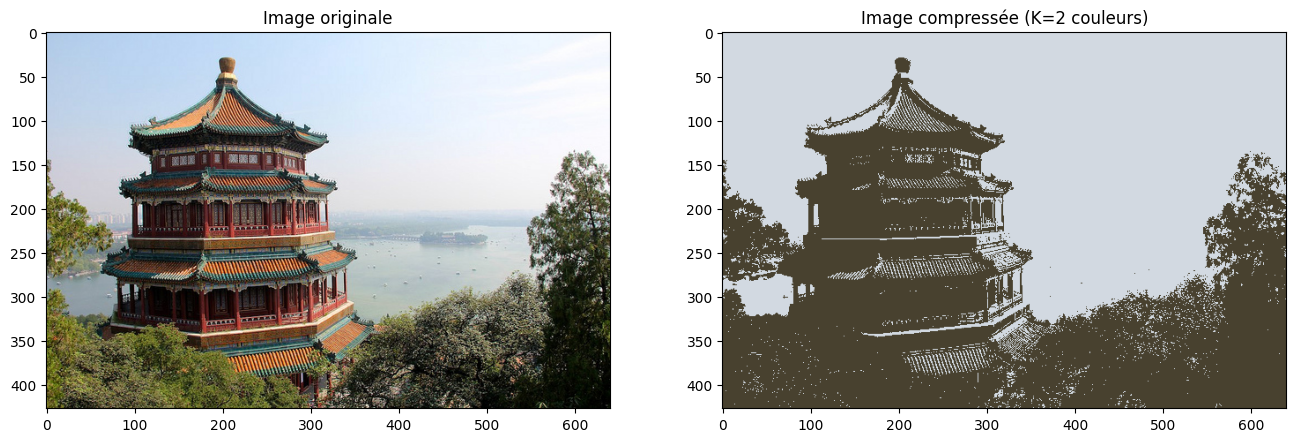

In [11]:
print(img.shape)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_title('Image originale')
ax1.imshow(image)
ax2.set_title('Image compressée (K=2 couleurs)')
ax2.imshow(img)
plt.show()

**Compression avec K = 4, 8, 16, 32 + courbe Elbow**

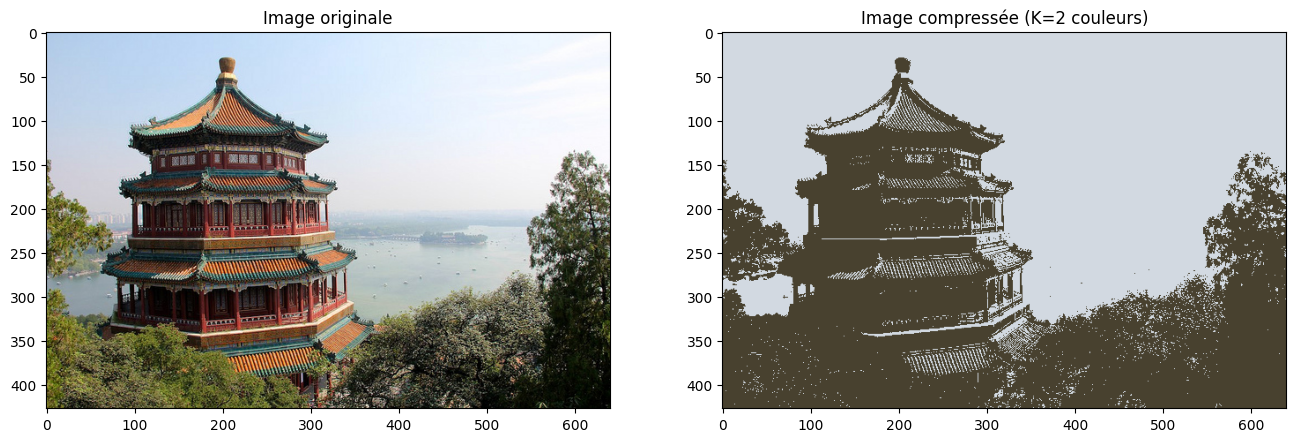

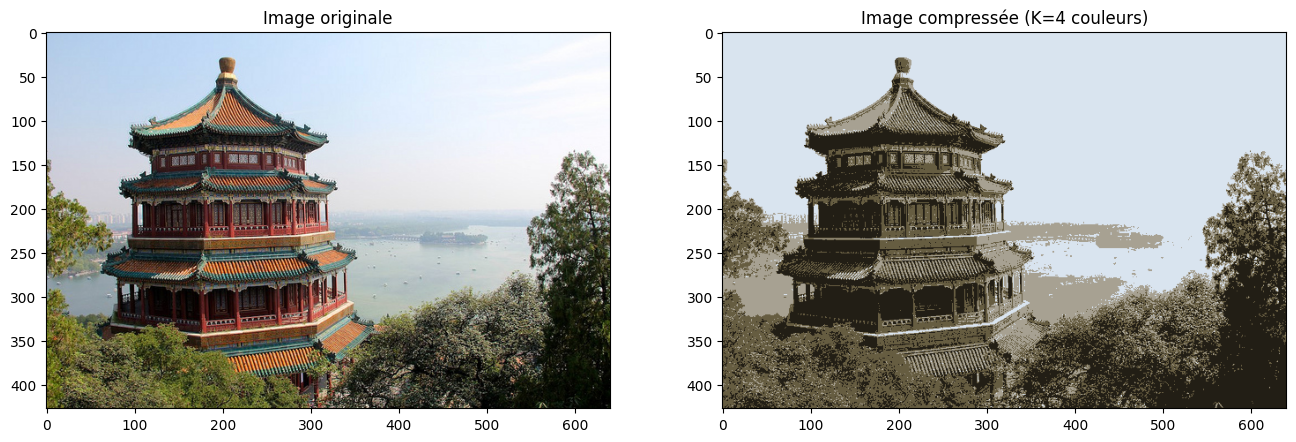

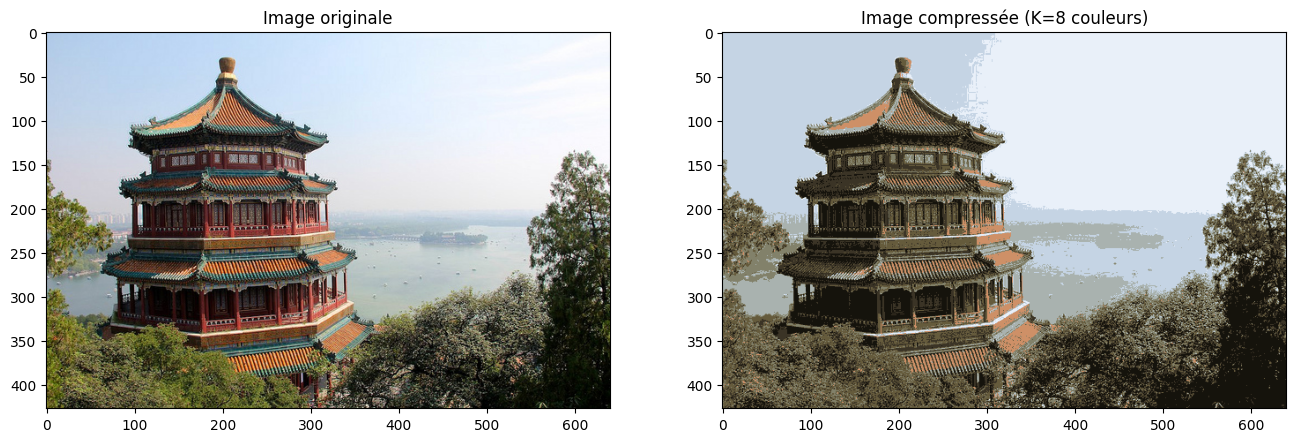

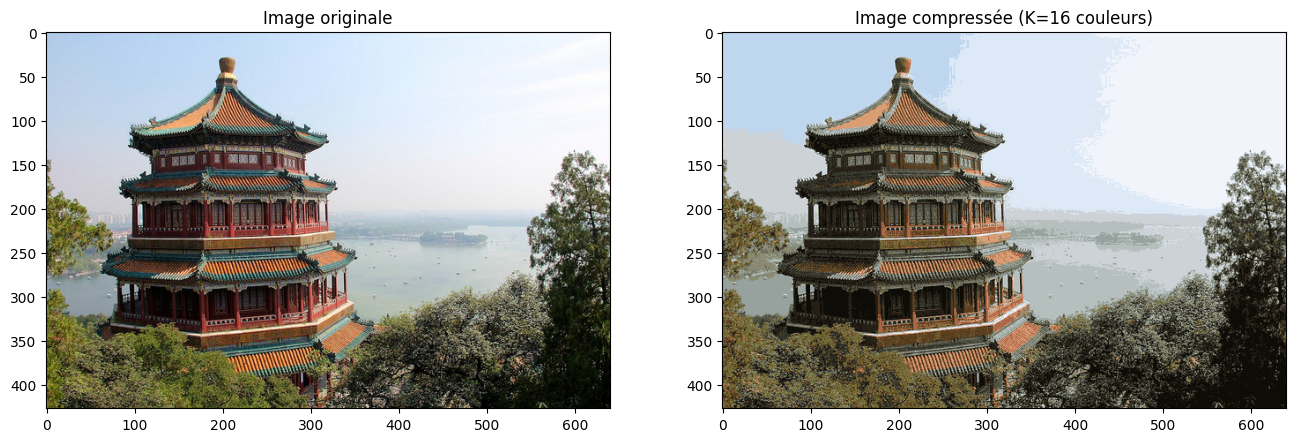

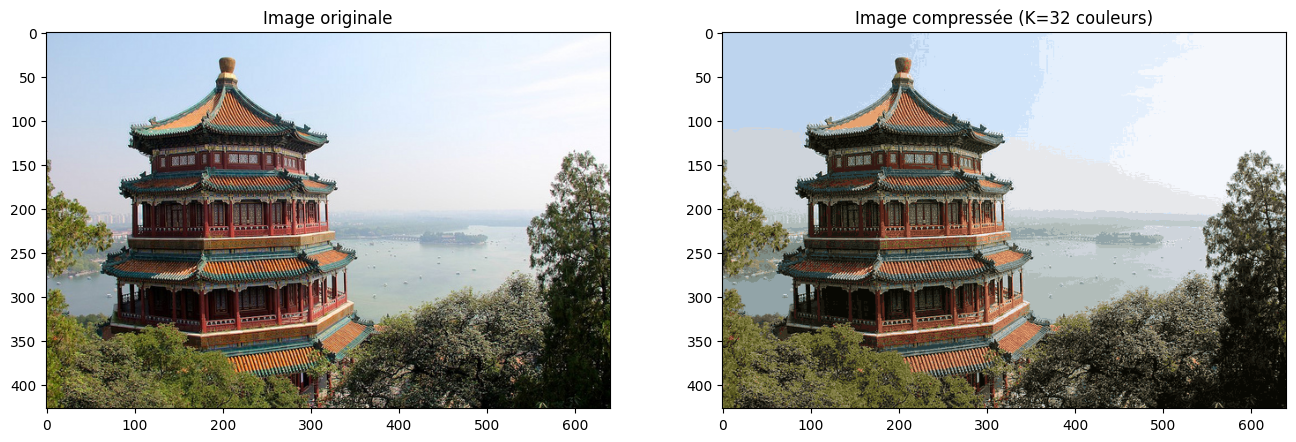

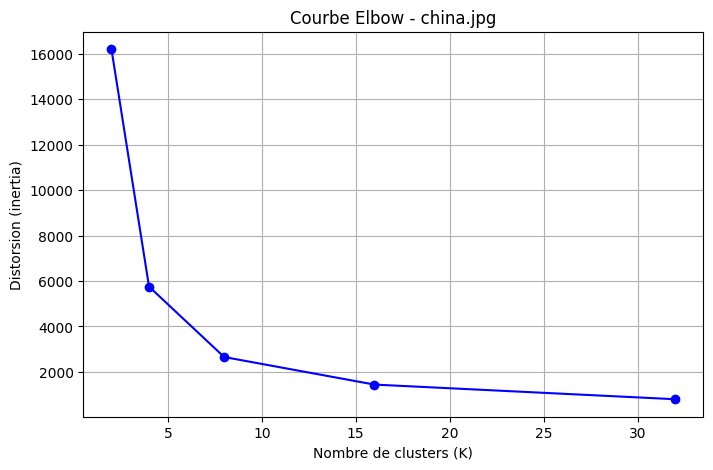

In [12]:
clusters_list = [2, 4, 8, 16, 32]
distortions = []

for k in clusters_list:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(image_p)
    
    distortions.append(model.inertia_)
    
    # Reconstruction
    img_k = np.reshape(model.cluster_centers_[model.labels_], image.shape)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.set_title('Image originale')
    ax1.imshow(image)
    ax2.set_title(f'Image compressée (K={k} couleurs)')
    ax2.imshow(img_k)
    plt.show()

# Courbe Elbow
plt.figure(figsize=(8, 5))
plt.plot(clusters_list, distortions, 'bo-')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Distorsion (inertia)')
plt.title('Courbe Elbow - china.jpg')
plt.grid(True)
plt.show()

**Compression de l'image flower.jpg + courbe Elbow**

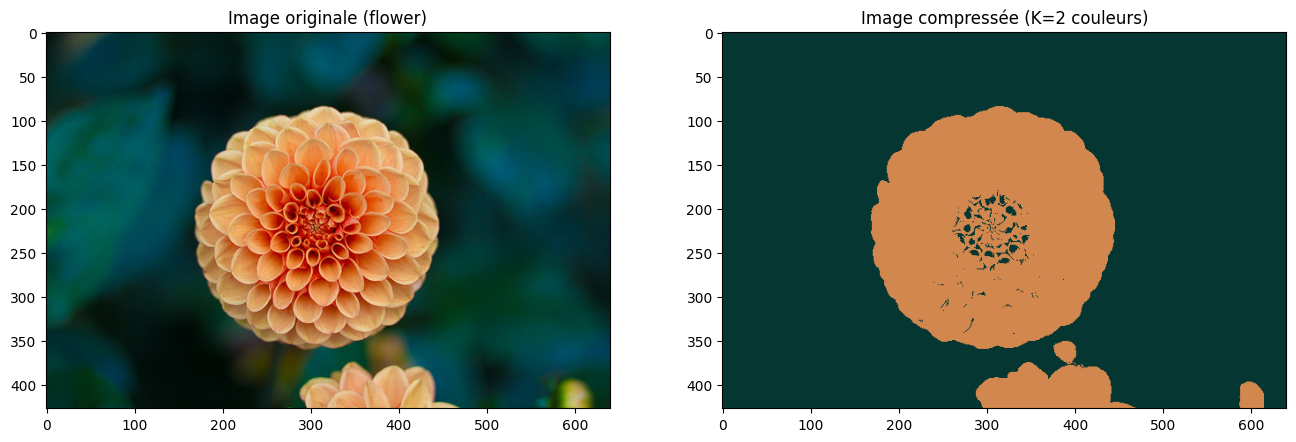

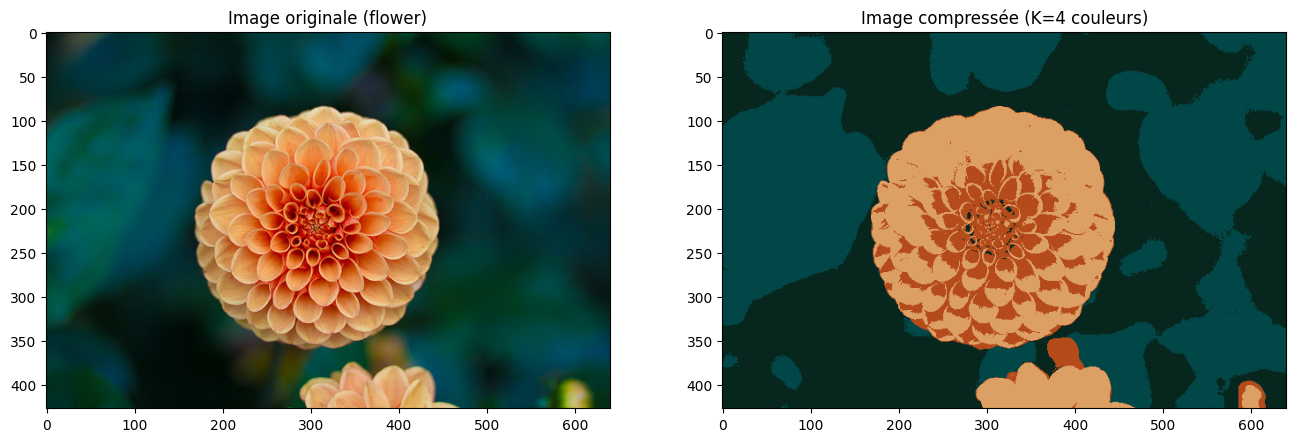

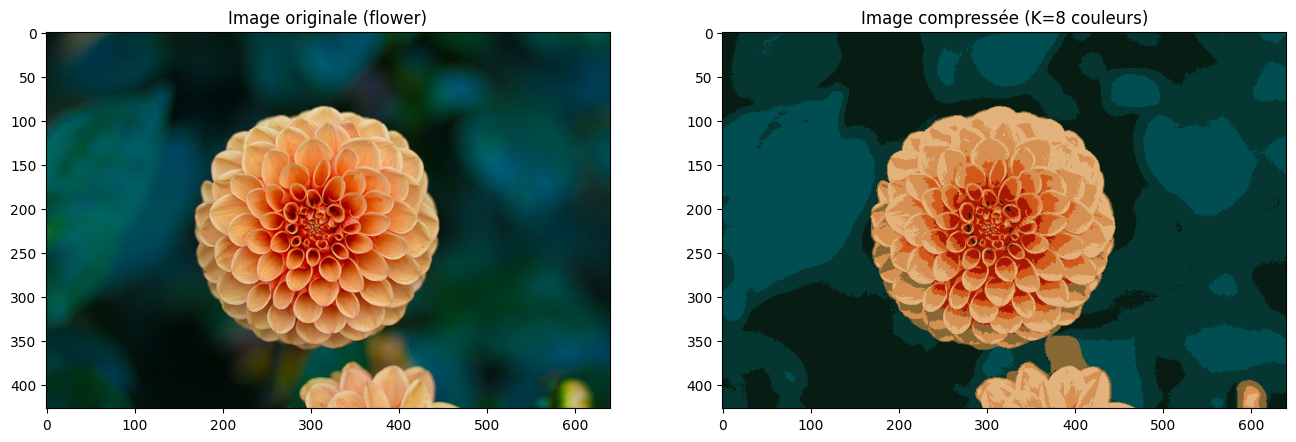

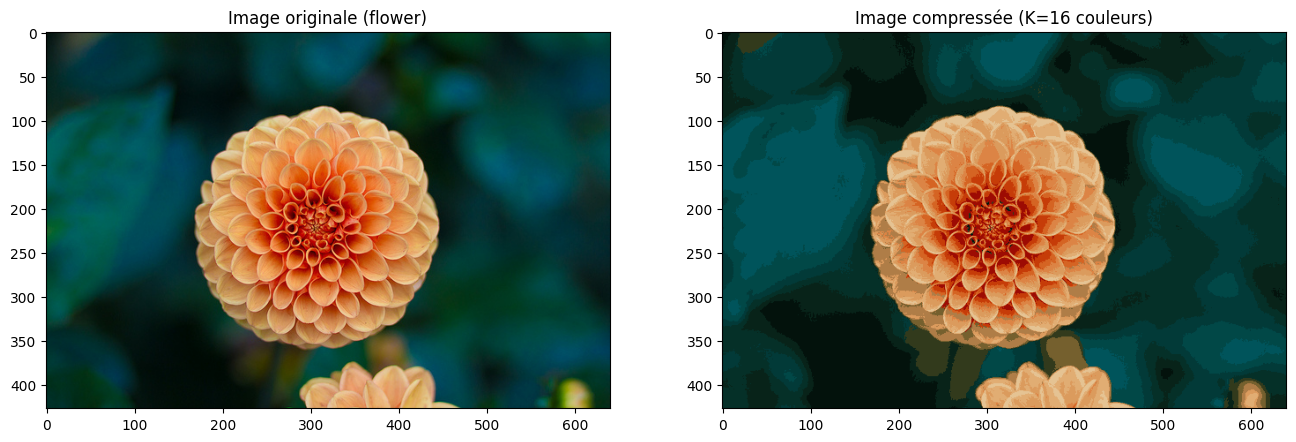

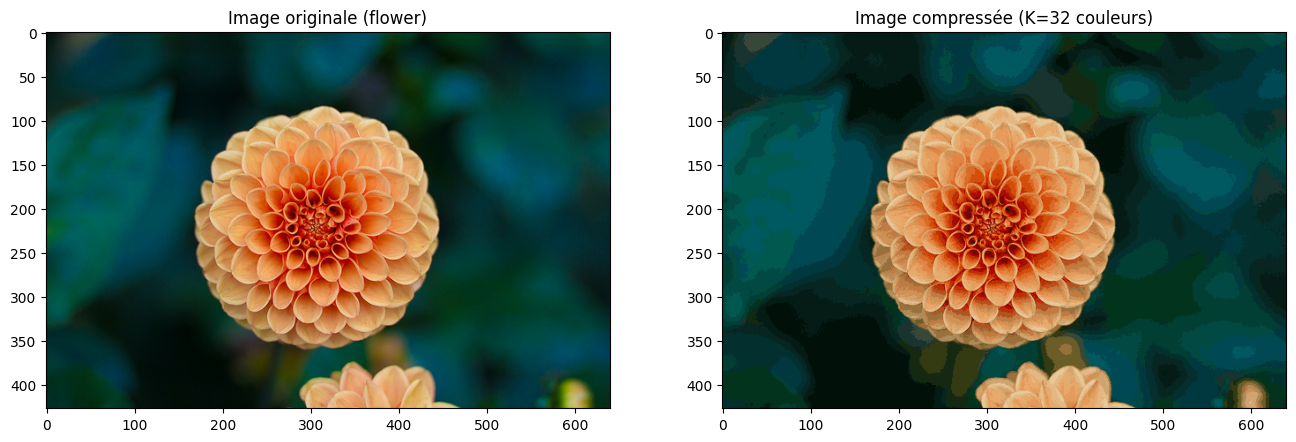

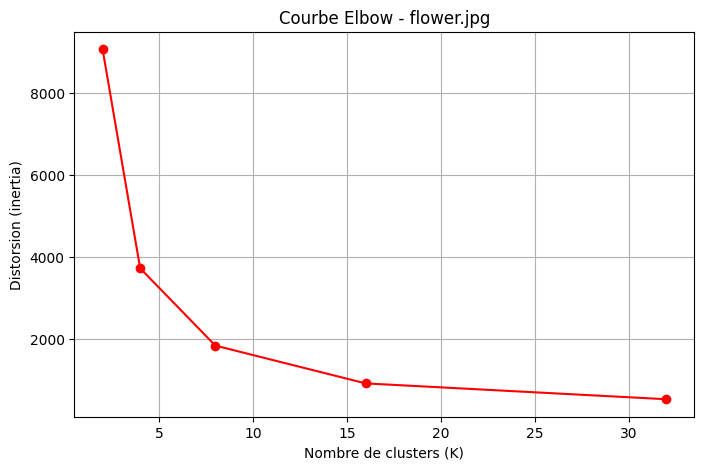

In [13]:
# Chargement de flower.jpg
flower = load_sample_image("flower.jpg")
rows_f, cols_f = flower.shape[0], flower.shape[1]
flower_p = flower.reshape(rows_f * cols_f, 3) / 255.0

distortions_flower = []

for k in clusters_list:
    model_f = KMeans(n_clusters=k, random_state=42, n_init=10)
    model_f.fit(flower_p)
    
    distortions_flower.append(model_f.inertia_)
    
    img_f = np.reshape(model_f.cluster_centers_[model_f.labels_], flower.shape)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.set_title('Image originale (flower)')
    ax1.imshow(flower)
    ax2.set_title(f'Image compressée (K={k} couleurs)')
    ax2.imshow(img_f)
    plt.show()

# Courbe Elbow flower
plt.figure(figsize=(8, 5))
plt.plot(clusters_list, distortions_flower, 'ro-')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Distorsion (inertia)')
plt.title('Courbe Elbow - flower.jpg')
plt.grid(True)
plt.show()